In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/neet-exam-score-rank-dataset/New Score-Rank.csv')

In [3]:
df_null = df[df['Expected Score'].isnull()]
df_new = df[df['Expected Score'].notnull()]
df_null.fillna("",inplace=True)
df_null

/tmp/ipykernel_23/2364960462.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_null.fillna("",inplace=True)


,Unnamed: 0,NEET_Rank,Expected Score
1,1,2,
2,2,3,
3,3,4,
4,4,5,
5,5,6,
...,...,...,...
1047995,1047995,1047996,
1047996,1047996,1047997,
1047997,1047997,1047998,
1047998,1047998,1047999,


In [4]:
X = df_new.iloc[:, 1:-1].values
y = df_new.iloc[:, -1].values
X_null = df_null.iloc[:, 1:-1].values
y_null = df_null.iloc[:, -1].values

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
model = regressor.fit(X_train, y_train)
y_null_predict = model.predict(X_null)

In [7]:
df_null['Expected Score'] = y_null_predict
df_null

/tmp/ipykernel_23/2050598608.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_null['Expected Score'] = y_null_predict


,Unnamed: 0,NEET_Rank,Expected Score
1,1,2,528.544065
2,2,3,528.543530
3,3,4,528.542994
4,4,5,528.542459
5,5,6,528.541924
...,...,...,...
1047995,1047995,1047996,-32.360268
1047996,1047996,1047997,-32.360804
1047997,1047997,1047998,-32.361339
1047998,1047998,1047999,-32.361874


In [8]:
# Concatenate the DataFrame and Series
df_newfull = pd.concat([df_new, df_null])

In [9]:
df_newfull

,Unnamed: 0,NEET_Rank,Expected Score
0,0,1,720.000000
9,9,10,710.000000
28,28,29,705.000000
29,29,30,705.000000
30,30,31,705.000000
...,...,...,...
1047995,1047995,1047996,-32.360268
1047996,1047996,1047997,-32.360804
1047997,1047997,1047998,-32.361339
1047998,1047998,1047999,-32.361874


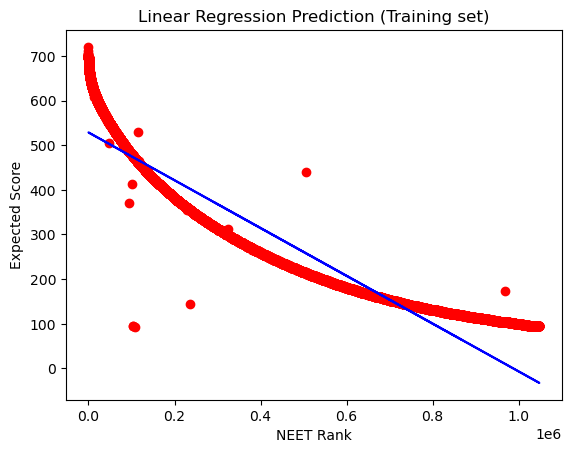

In [10]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train,model.predict(X_train), color = 'blue')
plt.title('Linear Regression Prediction (Training set)')
plt.xlabel('NEET Rank')
plt.ylabel('Expected Score')
plt.show()

In [11]:
dfscore=pd.read_csv("/kaggle/input/bdm-dataset/Merged_data.csv")

In [12]:
dfscore

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0.0,2.0
1,1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0.0,3.0
2,2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0.0,4.0
3,3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0.0,5.0
4,4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0.0,5.0
...,...,...,...,...,...,...,...,...,...
319,319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000,NaN,25.0
320,320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000,NaN,18.0
321,321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000,NaN,18.0
322,322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,NaN,3.0


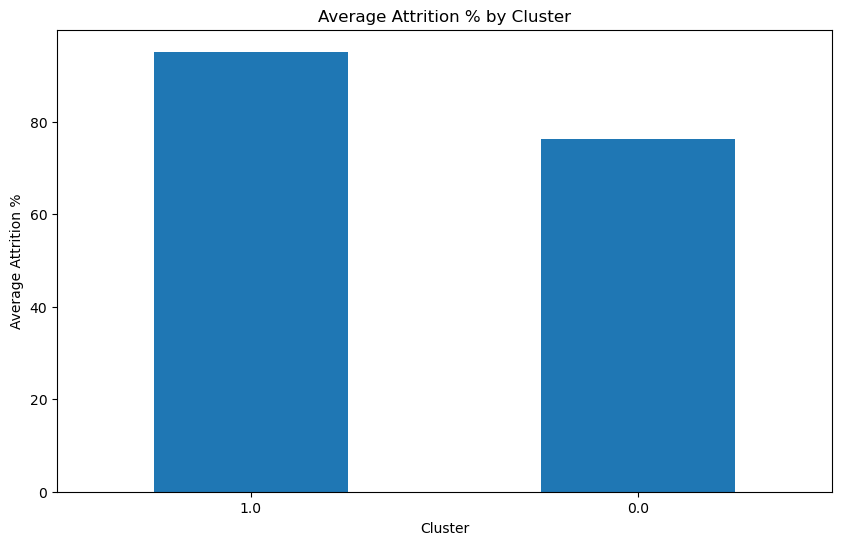

In [13]:
plt.figure(figsize=(10, 6))
cluster_avg_attrition = dfscore.groupby('Cluster')['Attrition %'].mean().sort_values(ascending=False)
cluster_avg_attrition.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Average Attrition %')
plt.title('Average Attrition % by Cluster')
plt.xticks(rotation=0)
plt.show()


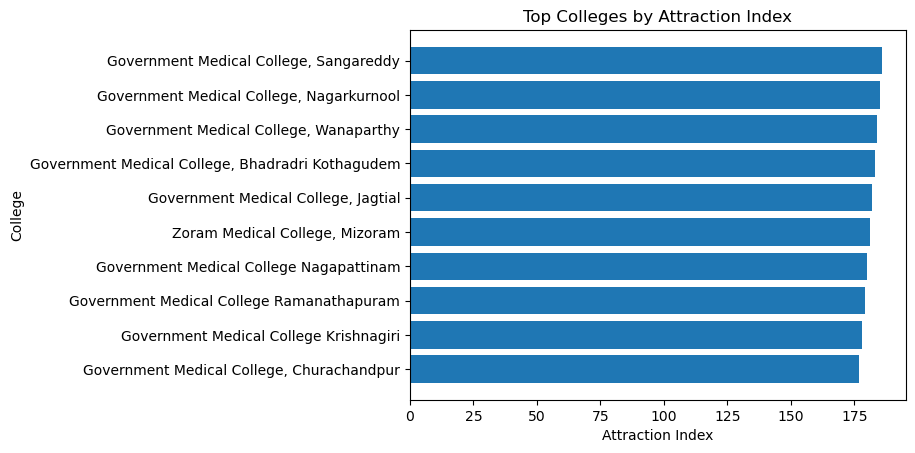

In [14]:
top_colleges = dfscore.nlargest(10, 'Attraction Index')
plt.barh(top_colleges['College name in college and course sheet 2023'], top_colleges['Attraction Index'])
plt.xlabel('Attraction Index')
plt.ylabel('College')
plt.title('Top Colleges by Attraction Index')
plt.gca().invert_yaxis()
plt.show()


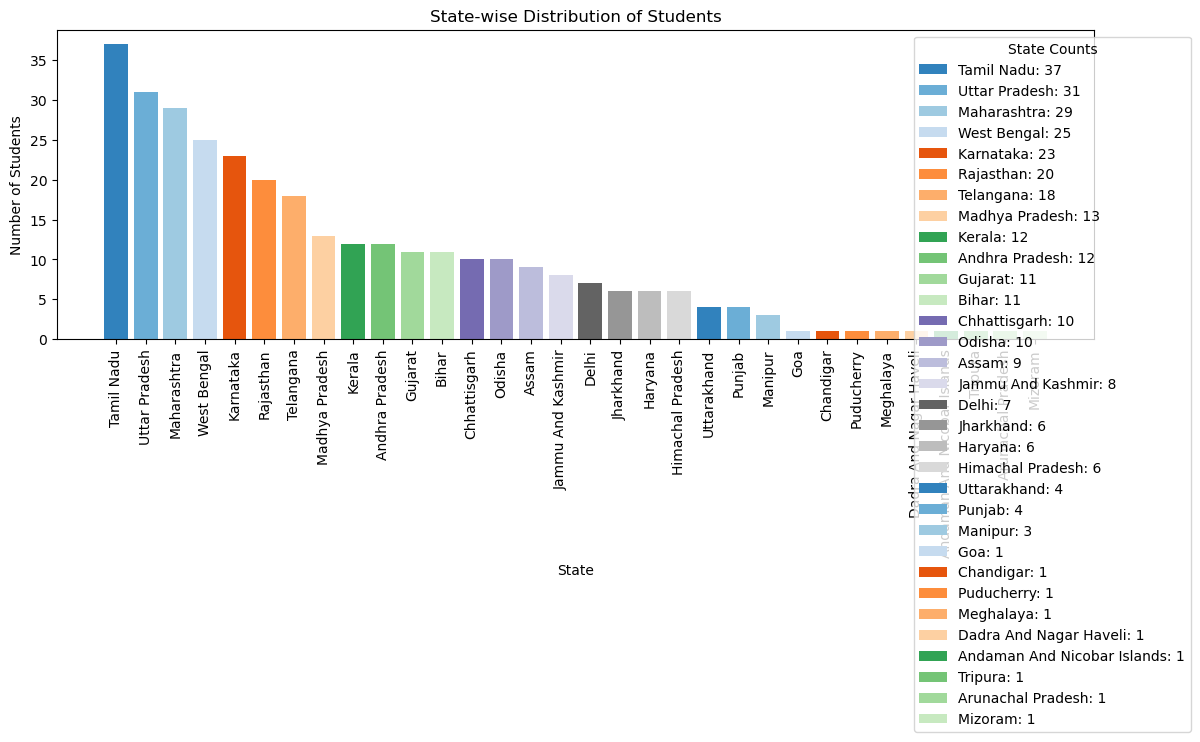

In [15]:
import matplotlib.pyplot as plt

state_counts = dfscore['STATE'].value_counts().sort_values(ascending=False)
colors = plt.cm.tab20c.colors[:len(state_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(state_counts.index, state_counts.values, color=colors)
plt.xlabel('State')
plt.ylabel('Number of Students')
plt.title('State-wise Distribution of Students')
plt.xticks(rotation=90)

# Adding a legend with color explanations
legend_labels = [f'{state}: {count}' for state, count in zip(state_counts.index, state_counts.values)]
plt.legend(bars, legend_labels, title='State Counts', loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()


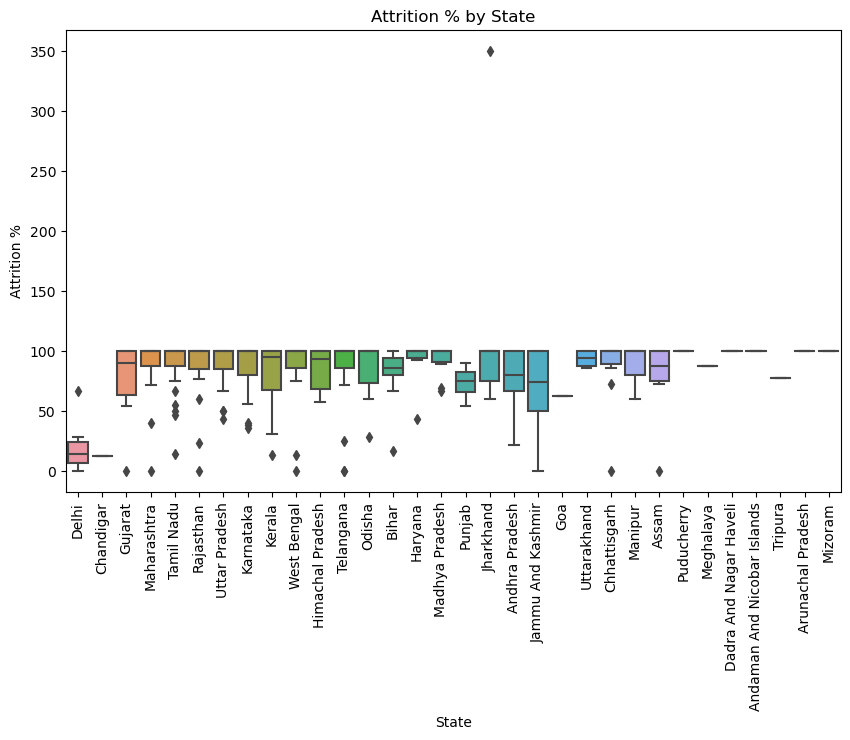

In [16]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=dfscore, x='STATE', y='Attrition %')
plt.xlabel('State')
plt.ylabel('Attrition %')
plt.title('Attrition % by State')
plt.xticks(rotation=90)
plt.show()


Mean Expected Score: 248.08504634635293
Median Expected Score: 243.0
Standard Deviation of Expected Score: 162.96211686834548
Minimum Expected Score: -32.36240929269525
Maximum Expected Score: 720.0


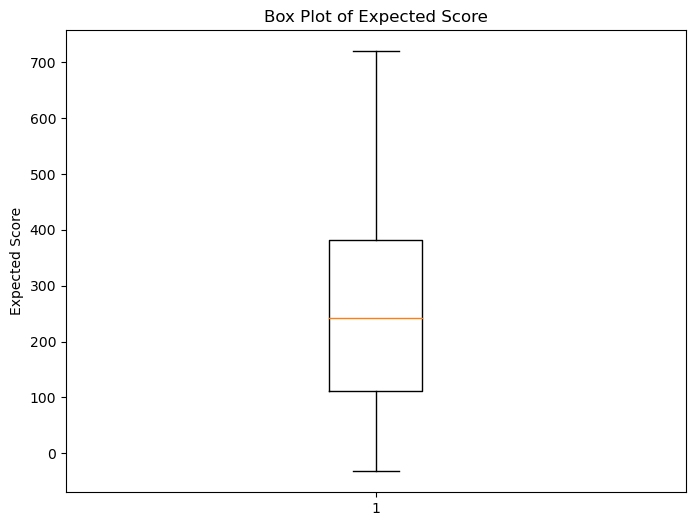

In [17]:
# Calculate summary statistics
mean_expected_score = df_newfull['Expected Score'].mean()
median_expected_score = df_newfull['Expected Score'].median()
std_expected_score = df_newfull['Expected Score'].std()
min_expected_score = df_newfull['Expected Score'].min()
max_expected_score = df_newfull['Expected Score'].max()

# Display summary statistics
print(f"Mean Expected Score: {mean_expected_score}")
print(f"Median Expected Score: {median_expected_score}")
print(f"Standard Deviation of Expected Score: {std_expected_score}")
print(f"Minimum Expected Score: {min_expected_score}")
print(f"Maximum Expected Score: {max_expected_score}")

# Box plot for Expected Score
plt.figure(figsize=(8, 6))
plt.boxplot(df_newfull['Expected Score'])
plt.title('Box Plot of Expected Score')
plt.ylabel('Expected Score')
plt.show()


In [18]:
# Calculate quartiles
q25 = df_newfull['Expected Score'].quantile(0.25)
q75 = df_newfull['Expected Score'].quantile(0.75)

# Display quartiles
print(f"25th Percentile (Q1): {q25}")
print(f"75th Percentile (Q3): {q75}")


25th Percentile (Q1): 112.0
75th Percentile (Q3): 382.0


R-squared for validation: 0.8926


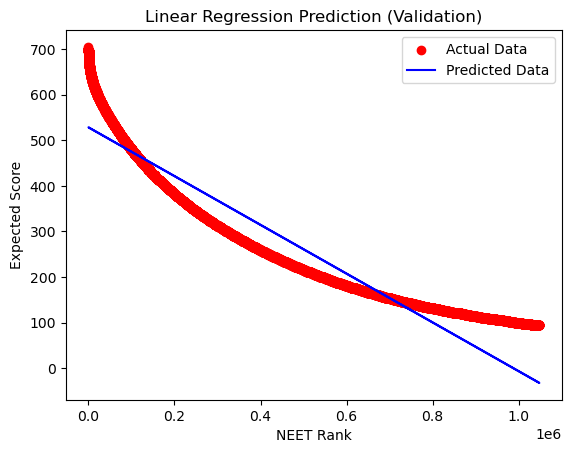

In [19]:
# Import necessary library
from sklearn.metrics import r2_score

X_val=X_test
y_val=y_test
y_val_pred = model.predict(X_val)

# Calculate R-squared for validation
r2_val = r2_score(y_val, y_val_pred)
print(f"R-squared for validation: {r2_val:.4f}")

# Plot the validated results
plt.scatter(X_val, y_val, color='red', label='Actual Data')
plt.plot(X_val, y_val_pred, color='blue', label='Predicted Data')
plt.title('Linear Regression Prediction (Validation)')
plt.xlabel('NEET Rank')
plt.ylabel('Expected Score')
plt.legend()
plt.show()

In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/neet-exam-score-rank-dataset/New Score-Rank.csv
/kaggle/input/bdm-dataset/Merged_data.csv


In [21]:
collegelist = pd.read_csv("/kaggle/input/bdm-dataset/Merged_data.csv")

In [22]:
collegelist.shape

(324, 9)

In [23]:
collegelist.head()

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0.0,2.0
1,1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0.0,3.0
2,2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0.0,4.0
3,3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0.0,5.0
4,4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0.0,5.0


In [24]:
collegelist.tail()

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
319,319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.0,NaN,25.0
320,320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.0,NaN,18.0
321,321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.0,NaN,18.0
322,322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.0,NaN,3.0
323,323,Jhargram Government Medical College & Hospital,West Bengal,All India,OP NO,0.0,0.0,NaN,21.0


In [25]:
filtered_df = collegelist[collegelist['Allotted Quota'] == 'All India']

In [26]:
filtered_df.shape

(324, 9)

In [27]:
filtered_df.tail()

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
319,319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.0,NaN,25.0
320,320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.0,NaN,18.0
321,321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.0,NaN,18.0
322,322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.0,NaN,3.0
323,323,Jhargram Government Medical College & Hospital,West Bengal,All India,OP NO,0.0,0.0,NaN,21.0


In [28]:
filtered_df.head()

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0.0,2.0
1,1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0.0,3.0
2,2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0.0,4.0
3,3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0.0,5.0
4,4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0.0,5.0


In [29]:
reset_df = filtered_df.reset_index(drop=True)

In [30]:
reset_df

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0.0,2.0
1,1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0.0,3.0
2,2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0.0,4.0
3,3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0.0,5.0
4,4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0.0,5.0
...,...,...,...,...,...,...,...,...,...
319,319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000,NaN,25.0
320,320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000,NaN,18.0
321,321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000,NaN,18.0
322,322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,NaN,3.0


In [31]:
reset_df = reset_df[reset_df['CAT'] == 'OP NO']

In [32]:
reset_df = reset_df.reset_index(drop=True)

In [33]:
reset_df.head()

,Unnamed: 0,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0.0,2.0
1,1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0.0,3.0
2,2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0.0,4.0
3,3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0.0,5.0
4,4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0.0,5.0


In [34]:
selected_columns = ['College name in college and course sheet 2023', 'STATE', 'Allotted Quota', 'CAT', 'R1 Closing', 'Attrition %']

In [35]:
new_df = reset_df[selected_columns]

In [36]:
new_df

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714
1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000
2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000
3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000
4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000
...,...,...,...,...,...,...
319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000
320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000
321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000


In [37]:
unique_values = new_df['STATE'].unique()
print(unique_values)

['Delhi' 'Chandigar' 'Gujarat' 'Maharashtra' 'Tamil Nadu' 'Rajasthan'
 'Uttar Pradesh' 'Karnataka' 'Kerala' 'West Bengal' 'Himachal Pradesh'
 'Telangana' 'Odisha' 'Bihar' 'Haryana' 'Madhya Pradesh' 'Punjab'
 'Jharkhand' 'Andhra Pradesh' 'Jammu And Kashmir' 'Goa' 'Uttarakhand'
 'Chhattisgarh' 'Manipur' 'Assam' 'Puducherry' 'Meghalaya'
 'Dadra And Nagar Haveli' 'Andaman And Nicobar Islands' 'Tripura'
 'Arunachal Pradesh' 'Mizoram']


In [38]:
df_with_r1closing = new_df[new_df['R1 Closing'].notnull()]

In [39]:
df_without_r1closing = new_df[new_df['R1 Closing'].isnull()]

In [40]:
df_with_r1closing

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714
1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000
2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000
3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000
4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000
...,...,...,...,...,...,...
319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000
320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000
321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000


In [41]:
df_without_r1closing.fillna('0',inplace=True)

/tmp/ipykernel_23/4030613384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_without_r1closing.fillna('0',inplace=True)


/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

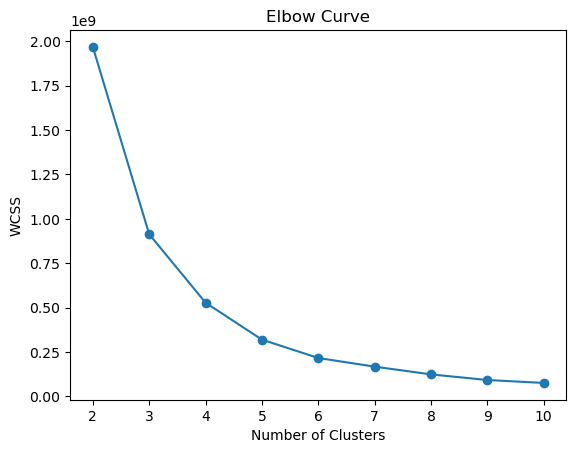

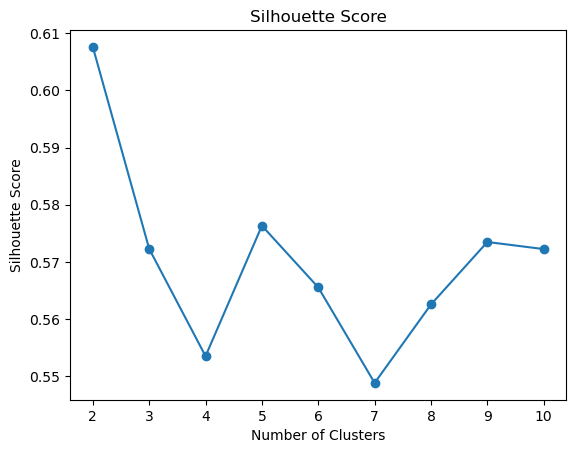

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assuming your DataFrame is called 'df' with columns 'College name', 'STATE', 'R1 Closing', and 'Attrition %'

# Select the columns for clustering
columns_for_clustering = ['R1 Closing', 'Attrition %']

# Determine the optimal number of clusters using the elbow method or silhouette score
wcss = []
silhouette_scores = []
max_clusters = min(10, len(df_with_r1closing) - 1)  # Set the maximum number of clusters based on the size of the dataset

for num_clusters in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(df_with_r1closing[columns_for_clustering])
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_with_r1closing[columns_for_clustering], kmeans.labels_))

# Plot the elbow curve
plt.plot(range(2, max_clusters + 1), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Curve')
plt.show()

# Plot the silhouette scores
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [43]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assuming your DataFrame is called 'df_with_r1closing' and contains the necessary columns

# Select the columns for clustering
columns_for_clustering = ['R1 Closing', 'Attrition %']

# Perform K-means clustering
num_clusters = 2  # Adjust the number of clusters as per your requirements
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(df_with_r1closing[columns_for_clustering])

# Assign the cluster labels to the DataFrame
df_with_r1closing['Cluster'] = kmeans.labels_

# Calculate the attraction index
df_with_r1closing['Attraction Index'] = df_with_r1closing.groupby('Cluster')['R1 Closing'].rank(ascending=True, method='min', na_option='bottom')

# Calculate and print the silhouette score
silhouette_avg = silhouette_score(df_with_r1closing[columns_for_clustering], kmeans.labels_)
print(f"Silhouette Score: {silhouette_avg:.2f}")


Silhouette Score: 0.61


/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [44]:
df_with_r1closing

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0,7.0
1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0,8.0
2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0,9.0
3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0,10.0
4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0,11.0
...,...,...,...,...,...,...,...,...
319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000,0,1.0
320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000,0,1.0
321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000,0,1.0
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,0,1.0


In [45]:
import pandas as pd

# Define the state priority based on your requirements
state_priority = {
    'Delhi': 1,
    'Uttar Pradesh': 2,
    'Rajasthan': 3,
    'Uttarakhand': 4,
    'Himachal Pradesh': 5,
    'Punjab': 6,
    'Jammu And Kashmir': 7,
    'Madhya Pradesh': 8,
    'Gujarat': 9,
    'Bihar': 10,
    'Jharkhand': 11,
    'Chhattisgarh': 12,
    'Karnataka': 13,
    'Kerala': 14,
    'Maharashtra': 15,
    'Odisha': 16,
    'Tamil Nadu': 17,
    'Telangana': 18,
    'Andhra Pradesh': 19,
    'Chandigarh': 20,
    'West Bengal': 21,
    'Haryana': 22,
    'Goa': 23,
    'Manipur': 24,
    'Assam': 25,
    'Puducherry': 26,
    'Meghalaya': 27,
    'Dadra And Nagar Haveli': 28,
    'Andaman And Nicobar Islands': 29,
    'Tripura': 30,
    'Arunachal Pradesh': 31,
    'Mizoram': 32
}

# Create a new column 'Attraction Index' based on the state priority
df_with_r1closing['Attraction Index_State'] = df_with_r1closing['STATE'].map(state_priority)
df_with_r1closing['Attraction Index_State'].fillna(0, inplace=True)

# Print the selected columns to observe the changes in attraction index
print(df_with_r1closing[['College name in college and course sheet 2023', 'R1 Closing', 'Attrition %', 'Attraction Index_State']])

         College name in college and course sheet 2023  R1 Closing  \
0              Maulana Azad Medical College, New Delhi        91.0   
1    Vardhman Mahavir Medical College & Safdarjung ...       129.0   
2    Atal Bihari Vajpayee Institute of Medical Scie...       173.0   
3    University College of Medical Sciences & GTB H...       191.0   
4               Government Medical College, Chandigarh       313.0   
..                                                 ...         ...   
319                     Dhubri Medical College, Dhubri         0.0   
320             Government Medical College, Mancherial         0.0   
321             Government Medical College, Ramagundam         0.0   
322         Government Medical College, Sri Ganganagar         0.0   
323     Jhargram Government Medical College & Hospital         0.0   

     Attrition %  Attraction Index_State  
0      14.285714                     1.0  
1       0.000000                     1.0  
2       0.000000              

In [46]:
df_with_r1closing

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index,Attraction Index_State
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0,7.0,1.0
1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0,8.0,1.0
2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0,9.0,1.0
3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0,10.0,1.0
4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0,11.0,0.0
...,...,...,...,...,...,...,...,...,...
319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000,0,1.0,25.0
320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000,0,1.0,18.0
321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000,0,1.0,18.0
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,0,1.0,3.0


In [47]:
df_with_r1closing['Sum'] = df_with_r1closing['Attraction Index'] + df_with_r1closing['Attraction Index_State']


In [48]:
df_with_r1closing

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index,Attraction Index_State,Sum
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0,7.0,1.0,8.0
1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0,8.0,1.0,9.0
2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0,9.0,1.0,10.0
3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0,10.0,1.0,11.0
4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0,11.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...
319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000,0,1.0,25.0,26.0
320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000,0,1.0,18.0,19.0
321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000,0,1.0,18.0,19.0
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,0,1.0,3.0,4.0


In [49]:
df_with_r1closing.drop(['Attraction Index', 'Attraction Index_State'], axis=1, inplace=True)

In [50]:
df_with_r1closing.rename(columns={'Sum': 'Attraction Index'}, inplace=True)

In [51]:
df_with_r1closing

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0,8.0
1,Vardhman Mahavir Medical College & Safdarjung ...,Delhi,All India,OP NO,129.0,0.000000,0,9.0
2,Atal Bihari Vajpayee Institute of Medical Scie...,Delhi,All India,OP NO,173.0,0.000000,0,10.0
3,University College of Medical Sciences & GTB H...,Delhi,All India,OP NO,191.0,20.000000,0,11.0
4,"Government Medical College, Chandigarh",Chandigar,All India,OP NO,313.0,12.500000,0,11.0
...,...,...,...,...,...,...,...,...
319,"Dhubri Medical College, Dhubri",Assam,All India,OP NO,0.0,0.000000,0,26.0
320,"Government Medical College, Mancherial",Telangana,All India,OP NO,0.0,0.000000,0,19.0
321,"Government Medical College, Ramagundam",Telangana,All India,OP NO,0.0,0.000000,0,19.0
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,0,4.0


In [52]:
merged_df = pd.concat([df_with_r1closing, df_without_r1closing], ignore_index=True)



# Print the merged and sorted DataFrame
print(merged_df)

         College name in college and course sheet 2023        STATE  \
0              Maulana Azad Medical College, New Delhi        Delhi   
1    Vardhman Mahavir Medical College & Safdarjung ...        Delhi   
2    Atal Bihari Vajpayee Institute of Medical Scie...        Delhi   
3    University College of Medical Sciences & GTB H...        Delhi   
4               Government Medical College, Chandigarh    Chandigar   
..                                                 ...          ...   
319                     Dhubri Medical College, Dhubri        Assam   
320             Government Medical College, Mancherial    Telangana   
321             Government Medical College, Ramagundam    Telangana   
322         Government Medical College, Sri Ganganagar    Rajasthan   
323     Jhargram Government Medical College & Hospital  West Bengal   

    Allotted Quota    CAT  R1 Closing  Attrition %  Cluster  Attraction Index  
0        All India  OP NO        91.0    14.285714      0.0        

In [53]:
merged_df.to_csv("Merged_data.csv")

In [54]:
merged_df.sort_values(by='Attraction Index', ascending=True, inplace=True)

In [55]:
merged_df

,College name in college and course sheet 2023,STATE,Allotted Quota,CAT,R1 Closing,Attrition %,Cluster,Attraction Index
322,"Government Medical College, Sri Ganganagar",Rajasthan,All India,OP NO,0.0,0.000000,0.0,4.0
152,"Government Medical College, Shahjahanpur, UP",Uttar Pradesh,All India,OP NO,9264.0,100.000000,1.0,5.0
151,"Government Medical College, Sirohi",Rajasthan,All India,OP NO,9256.0,100.000000,1.0,5.0
0,"Maulana Azad Medical College, New Delhi",Delhi,All India,OP NO,91.0,14.285714,0.0,8.0
153,Veer Chandra Singh Garhwali Govt. Medical Sc. ...,Uttarakhand,All India,OP NO,9353.0,87.500000,1.0,8.0
...,...,...,...,...,...,...,...,...
313,"Government Medical College, Jagtial",Telangana,All India,OP NO,17233.0,100.000000,1.0,182.0
314,"Government Medical College, Bhadradri Kothagudem",Telangana,All India,OP NO,17316.0,100.000000,1.0,183.0
315,"Government Medical College, Wanaparthy",Telangana,All India,OP NO,17323.0,100.000000,1.0,184.0
316,"Government Medical College, Nagarkurnool",Telangana,All India,OP NO,17366.0,100.000000,1.0,185.0


In [56]:
# Calculate the statistics for the "R1 Closing" column
mean_r1_closing = df_with_r1closing['R1 Closing'].mean()
std_r1_closing = df_with_r1closing['R1 Closing'].std()
min_r1_closing = df_with_r1closing['R1 Closing'].min()
max_r1_closing = df_with_r1closing['R1 Closing'].max()

# Display the calculated statistics
print(f"Mean R1 Closing: {mean_r1_closing}")
print(f"Standard Deviation of R1 Closing: {std_r1_closing}")
print(f"Minimum R1 Closing: {min_r1_closing}")
print(f"Maximum R1 Closing: {max_r1_closing}")


Mean R1 Closing: 9202.58024691358
Standard Deviation of R1 Closing: 4696.478129424844
Minimum R1 Closing: 0.0
Maximum R1 Closing: 17401.0


In [57]:
# Calculate the statistics for the "Attrition %" column
mean_attrition = df_with_r1closing['Attrition %'].mean()
std_attrition = df_with_r1closing['Attrition %'].std()
min_attrition = df_with_r1closing['Attrition %'].min()
max_attrition = df_with_r1closing['Attrition %'].max()

# Display the calculated statistics
print(f"Mean Attrition %: {mean_attrition}")
print(f"Standard Deviation of Attrition %: {std_attrition}")
print(f"Minimum Attrition %: {min_attrition}")
print(f"Maximum Attrition %: {max_attrition}")


Mean Attrition %: 84.61055790916902
Standard Deviation of Attrition %: 29.98624876933288
Minimum Attrition %: 0.0
Maximum Attrition %: 350.0


In [58]:
# Calculate the statistics for the "Cluster" column
mean_cluster = df_with_r1closing['Cluster'].mean()

# Display the calculated statistics
print(f"Mean Cluster: {mean_cluster}")


Mean Cluster: 0.5185185185185185


In [59]:
# Calculate the statistics for the "Attraction Index" column
mean_attraction_index = df_with_r1closing['Attraction Index'].mean()
std_attraction_index = df_with_r1closing['Attraction Index'].std()
min_attraction_index = df_with_r1closing['Attraction Index'].min()
max_attraction_index = df_with_r1closing['Attraction Index'].max()

# Display the calculated statistics
print(f"Mean Attraction Index: {mean_attraction_index}")
print(f"Standard Deviation of Attraction Index: {std_attraction_index}")
print(f"Minimum Attraction Index: {min_attraction_index}")
print(f"Maximum Attraction Index: {max_attraction_index}")


Mean Attraction Index: 94.45679012345678
Standard Deviation of Attraction Index: 48.952317580232496
Minimum Attraction Index: 4.0
Maximum Attraction Index: 186.0


In [60]:
# Display clusters and their corresponding attraction indexes
cluster_attraction = df_with_r1closing.groupby('Cluster')['Attraction Index'].mean()
print("Clusters and Their Corresponding Attraction Indexes:")
for cluster, attraction_index in cluster_attraction.items():
    print(f"Cluster {cluster}: Attraction Index {attraction_index:.2f}")


Clusters and Their Corresponding Attraction Indexes:
Cluster 0: Attraction Index 89.23
Cluster 1: Attraction Index 99.31


In [61]:
merged_df.to_csv("Attraction_Index_AllIndia_OPNO_file.csv")